## Ejercicio 1.

Implemente las estructuras de datos y algoritmos básicos para la solución de un **problema mediante algoritmos genéticos.** Pruebe estas rutinas y compare los resultados con un método de gradiente descendiente para buscar el mı́nimo global de las siguientes funciones:

#### A.

$$f(x)=-x\ sin(\sqrt{|x|}), \quad x \in [-512,\ 512]$$


In [21]:
import numpy as np
import random 
import matplotlib.pyplot as plt

In [22]:
def decodificar(individuo,cantBits,alpha,beta): 
    d = 0
    for i in range(cantBits):
        d += 2**(cantBits-1-i)*individuo[i]

    x = alpha + d*((beta-alpha)/(2**cantBits - 1))
    
    return x

In [23]:
def funcion(x):
    return -x * np.sin(np.sqrt(np.abs(x)))

def derivada_funcion(x):
    return -np.sin(np.sqrt(np.abs(x))) - (np.sqrt(np.abs(x)) / 2) * np.cos(np.sqrt(np.abs(x)))

In [24]:
def funcion_aptitud(individuo,cantBits,alpha,beta):
    x = decodificar(individuo,cantBits,alpha,beta)

    fx = -x*np.sin(np.sqrt(abs(x)))
    #fitness = 500-fx
    fitness = -fx
    return fitness

In [25]:
def evaluar_poblacion(poblacion,cantBits, alpha,beta):
    aptitudes = np.zeros(poblacion.shape[0])

    for i in range(poblacion.shape[0]):
        aptitud = funcion_aptitud(poblacion[i,:],cantBits, alpha,beta)
        aptitudes[i] = aptitud
    
    return aptitudes 
    

In [26]:
def seleccion_natural(aptitudes):
    orden = np.arange(0,aptitudes.shape[0])
    matriz = np.c_[aptitudes,orden]

    indices = np.argsort(matriz[:, 0])[::-1]
    matriz = matriz[indices]

    cantVentanas = 10
    venta_act = 0

    padres = np.zeros((cantVentanas,))

    while venta_act<cantVentanas:
        tam_ventana = int((aptitudes.shape[0]-1)*((cantVentanas-venta_act)/cantVentanas))
        padres[venta_act] = matriz[random.randint(0,tam_ventana),1]
        venta_act += 1

    return padres

In [27]:
def operador_variacion(poblacion,padres,ind_mejorAptitud):
    nueva_poblacion = [poblacion[ind_mejorAptitud,:].copy()]

    prob_mutacion = 5 #%
    #mutacion
    for i in range(padres.shape[0]-1):
        padre = int(padres[i])
        cromosoma_nuevo = poblacion[padre,:].copy()
        if(random.randint(0,100)<prob_mutacion):
            bit_mutar = random.randint(0,poblacion.shape[1]-1)
            cromosoma_nuevo[bit_mutar] = not(cromosoma_nuevo[bit_mutar])
        nueva_poblacion.append(cromosoma_nuevo)


    #cruza
    for i in range(padres.shape[0]): 
        for j in range(i+1,padres.shape[0]):
            cant_bit_intercambio = random.randint(1,poblacion.shape[1]-1)
            padre1 = int(padres[i])
            padre2 = int(padres[j])
            hijo1 = np.r_[poblacion[padre1,0:cant_bit_intercambio],poblacion[padre2,cant_bit_intercambio:]]
            hijo2 = np.r_[poblacion[padre2,0:cant_bit_intercambio],poblacion[padre1,cant_bit_intercambio:]]
            nueva_poblacion.append(hijo1)
            nueva_poblacion.append(hijo2)

    poblacion = np.array(nueva_poblacion)
    return poblacion         

In [28]:
def graficar(hist_aptitudes): 
    # hist_aptitudes tiene forma (individuos, generaciones)
    generaciones = np.arange(hist_aptitudes.shape[1])
        
    # Calculo en los individuos (filas)
    maximos = np.max(hist_aptitudes, axis=0)
    minimos = np.min(hist_aptitudes, axis=0)
    promedios = np.mean(hist_aptitudes, axis=0)
        
    plt.figure(figsize=(9, 5))
    plt.plot(generaciones, maximos, label="Mejor aptitud (Máximo)", color="green")
    plt.plot(generaciones, promedios, label="Aptitud promedio", color="blue", linestyle="--")
    plt.plot(generaciones, minimos, label="Peor aptitud (Mínimo)", color="red")
        
    plt.xlabel("Generación")
    plt.ylabel("Aptitud")
    plt.title("Historial de convergencia del Algoritmo Evolutivo")
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.legend()
    plt.show()

In [29]:
def grad_desc(x_inicial, mu, iteraciones, alpha=-512, beta=512):
    x = x_inicial

    for _ in range(iteraciones):
        grad = derivada_funcion(x)
        x_nuevo = x - mu * grad
        x = x_nuevo

    return x

12
Algoritmo Evolutivo: x = 420.91 y el minimo es f(x) = -418.98
Gradiente Descendente x = 203.8143 y el minimo es f(x) = -201.8432


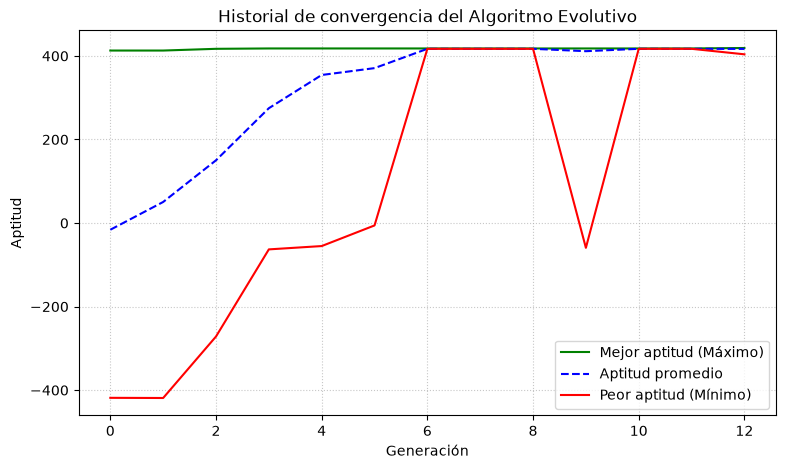

In [30]:
alpha = -512
beta = 512

N = 100
cantBitsInd = 10
cant_max_generaciones = 3000 

poblacion = np.random.randint(0,2,size=(N,cantBitsInd))

aptitudes = evaluar_poblacion(poblacion,cantBitsInd,alpha,beta)
mejorAptidud = np.max(aptitudes) 
ind_mejorAptitud = np.argmax(aptitudes)

generacion = 0
aptitudDeseada = 418.6

histAptitudes = [aptitudes]

while  mejorAptidud<aptitudDeseada and generacion < cant_max_generaciones:
    padres = seleccion_natural(aptitudes)
    poblacion = operador_variacion(poblacion,padres,ind_mejorAptitud)
    aptitudes = evaluar_poblacion(poblacion,cantBitsInd,alpha,beta)
    mejorAptidud = np.max(aptitudes) 
    ind_mejorAptitud = np.argmax(aptitudes)
    histAptitudes.append(aptitudes)
    generacion += 1

indiceMejorAptitud = np.argmax(aptitudes)
cromosoma = poblacion[indiceMejorAptitud,:]

print(generacion)
x = decodificar(cromosoma,cantBitsInd,alpha,beta)
print(f"Algoritmo Evolutivo: x = {x:.2f} y el minimo es f(x) = {funcion(x):.2f}")

x_inicial = 300
mu = 0.5
iter = 1000
x_min = grad_desc(x_inicial, mu, iter)
print(f"Gradiente Descendente x = {x_min:.4f} y el minimo es f(x) = {funcion(x_min):.4f}")

histAptitudes = np.array(histAptitudes).T
graficar(histAptitudes)